# MiST: Multilingual Symptom Triage for Immigrant Populations
## XLM-RoBERTa + SHAP Explainability | PyTorch Implementation
**Author:** Azizur Rahman  
**Paper:** *MiST: A Multilingual Symptom Triage Framework for Immigrant Populations Using XLM-RoBERTa and Cross-Lingual Explainability*  
**Target Venue:** Journal of Biomedical Informatics / EMNLP Clinical NLP Workshop

---
### Notebook Contents
| # | Section |
|---|---------|
| 1 | Environment Setup & Imports |
| 2 | MiST Dataset Construction |
| 3 | Preprocessing & PyTorch Dataset |
| 4 | Baseline — mBERT |
| 5 | XLM-RoBERTa Two-Stage Fine-Tuning |
| 6 | Training Curves |
| 7 | Evaluation & CTEI Metric |
| 8 | SHAP Token-Level Explainability |
| 9 | Zero-Shot Transfer to Urdu |
| 10 | Results Summary & Paper Tables |


## 1. Environment Setup & Imports

In [3]:
# Install required packages (run once)
!pip install transformers datasets torch scikit-learn
!pip install shap transformers-interpret
!pip install seaborn matplotlib pandas numpy tqdm
!pip install sentencepiece protobuf


In [4]:
import os, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score,
    precision_score, recall_score, confusion_matrix,
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

LABEL2ID = {"Routine": 0, "Urgent": 1, "Emergency": 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = 3


Device : cpu
PyTorch: 2.12.0


## 2. MiST Dataset Construction
Symptom descriptions in **English, Spanish, Hindi, and Bengali** across three urgency tiers.  
Dataset is constructed using a clinically-grounded template generation pipeline (see `generate_dataset.py`).  
Split is performed on base data **before** augmentation to prevent data leakage.

In [ ]:
DATASET_DIR = "dataset"  # folder containing per-language CSV files

URDU_SYMPTOMS = {
    "Emergency": [
        "Baye bazoo tak phailta seene ka shadeed dard, paseena aur matli ke saath",
        "Achanak behoshi, kisi bhi mahrik par koi rad-amal nahi",
        "Saans lene mein bahut mushkil, honth neele par rahe hain",
        "Shadeed allergic rad-amal, gala sooj raha hai, nigalna mushkil",
        "Achanak zindagi ka badtareen sardard, gardan akri hui hai",
    ],
    "Urgent": [
        "Girne ke baad kalai mein mumkina fracture, sojan aur neelahat",
        "Chhe ghante se musalsal qay, paani bhi nahi ruk raha",
        "Kaan mein dard, kuch bah raha hai aur kal se kam sunai de raha hai",
    ],
    "Routine": [
        "Teen din se halki khansi, bukhar nahi, gale mein halki jalan",
        "Bazoo par chhota daana, koi aur alamaat nahi, thodi khaarish",
    ],
}

PREFIXES = [
    "Patient reports: ", "Chief complaint: ", "Patient states: ",
    "Presenting with: ", "Complaints of: ", "Reports experiencing: ",
    "Describes: ", "Presenting symptom: ", "States: ", "Notes: ",
    "Experiencing: ", "Feels: ", "Currently: ", "Suffering from: ",
]


def load_base_dataset(data_dir):
    """Load CSVs without augmentation — used for clean splitting."""
    csv_files = sorted([f for f in os.listdir(data_dir) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} language files: {csv_files}")
    frames = []
    for fname in csv_files:
        lang_df = pd.read_csv(os.path.join(data_dir, fname))
        print(f"  {fname}: {len(lang_df)} rows")
        frames.append(lang_df)
    base_df = pd.concat(frames, ignore_index=True)
    base_df["label"] = base_df["label"].map(LABEL2ID)
    return base_df


def augment_df(df, augment_factor=5):
    """Augment a dataframe by prepending clinical prefixes. Apply ONLY to train set."""
    rows = []
    for _, row in df.iterrows():
        rows.append({"text": row["text"], "label": row["label"], "language": row["language"]})
        for i in range(augment_factor):
            pfx = PREFIXES[i % len(PREFIXES)]
            rows.append({"text": pfx + row["text"], "label": row["label"], "language": row["language"]})
    result = pd.DataFrame(rows)
    result = result.sample(frac=1, random_state=SEED).reset_index(drop=True)
    return result


# Load base data (no augmentation yet)
base_df = load_base_dataset(DATASET_DIR)
print(f"\nBase dataset: {len(base_df)} rows")
print(base_df.groupby(["language", "label"])["text"].count().unstack().rename(columns=ID2LABEL))


In [ ]:
# ── Split FIRST on base data (no leakage), THEN augment train only ──
base_df["strat_key"] = base_df["language"] + "_" + base_df["label"].astype(str)

train_base, temp_base = train_test_split(base_df, test_size=0.30, stratify=base_df["strat_key"], random_state=SEED)
val_base,   test_base = train_test_split(temp_base, test_size=0.50, stratify=temp_base["strat_key"], random_state=SEED)

# Augment ONLY the training set.
# factor=2 → 3× training data (original + 2 prefix variants per sentence).
# Keeping this moderate prevents epoch-1 memorisation of synthetic patterns
# while still giving the model diverse input at each step.
train_df = augment_df(train_base, augment_factor=2)
val_df   = val_base.reset_index(drop=True)
test_df  = test_base.reset_index(drop=True)

print(f"Base split  — Train: {len(train_base)} | Val: {len(val_base)} | Test: {len(test_base)}")
print(f"After augment — Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nLabel distribution in train (augmented):")
print(train_df["label"].map(ID2LABEL).value_counts())

## 3. Preprocessing & PyTorch Dataset

In [9]:
MODEL_NAME = "xlm-roberta-base"
MAX_LEN    = 128
BATCH_SIZE = 32

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class SymptomDataset(Dataset):
    def __init__(self, dataframe, tok, max_len=MAX_LEN):
        self.texts  = dataframe["text"].tolist()
        self.labels = dataframe["label"].tolist()
        self.tok    = tok
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_ds = SymptomDataset(train_df, tokenizer)
val_ds   = SymptomDataset(val_df,   tokenizer)
test_ds  = SymptomDataset(test_df,  tokenizer)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")


Train batches: 40 | Val: 9 | Test: 9


## 4. Training Utilities

In [11]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc="Training", leave=False):
        ids   = batch["input_ids"].to(device)
        mask  = batch["attention_mask"].to(device)
        labs  = batch["labels"].to(device)
        optimizer.zero_grad()
        out  = model(input_ids=ids, attention_mask=mask, labels=labs)
        out.loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += out.loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    preds, trues, total_loss = [], [], 0
    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labs = batch["labels"].to(device)
            out  = model(input_ids=ids, attention_mask=mask, labels=labs)
            preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
            trues.extend(labs.cpu().numpy())
            total_loss += out.loss.item()
    macro_f1 = f1_score(trues, preds, average="macro")
    return macro_f1, total_loss / len(loader), preds, trues


## 4b. Baseline — mBERT

In [13]:
CKPT_MBERT = "checkpoints/mbert"
CKPT_XLMR  = "checkpoints/xlmr"

def run_training(model_name, train_df, val_df, epochs=4, lr=2e-5, warmup_ratio=0.1, ckpt_dir=None):
    if ckpt_dir and os.path.exists(os.path.join(ckpt_dir, "config.json")):
        print(f"Checkpoint found at {ckpt_dir} — skipping training, loading saved model.")
        model = AutoModelForSequenceClassification.from_pretrained(
            ckpt_dir, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID
        ).to(DEVICE)
        return model, {"train_loss": [], "val_loss": [], "val_f1": []}

    tok = AutoTokenizer.from_pretrained(model_name)
    train_ldr = DataLoader(SymptomDataset(train_df, tok), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_ldr   = DataLoader(SymptomDataset(val_df,   tok), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID
    ).to(DEVICE)
    optimizer    = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps  = len(train_ldr) * epochs
    scheduler    = get_linear_schedule_with_warmup(optimizer, int(total_steps * warmup_ratio), total_steps)
    best_f1, best_state, history = 0, None, {"train_loss": [], "val_loss": [], "val_f1": []}
    for epoch in range(1, epochs + 1):
        tl = train_epoch(model, train_ldr, optimizer, scheduler, DEVICE)
        vf, vl, _, _ = evaluate(model, val_ldr, DEVICE)
        history["train_loss"].append(tl); history["val_loss"].append(vl); history["val_f1"].append(vf)
        print(f"Epoch {epoch}/{epochs}  train_loss={tl:.4f}  val_loss={vl:.4f}  val_F1={vf:.4f}")
        if vf > best_f1:
            best_f1  = vf
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    if ckpt_dir:
        os.makedirs(ckpt_dir, exist_ok=True)
        model.save_pretrained(ckpt_dir)
        tok.save_pretrained(ckpt_dir)
        print(f"Checkpoint saved to {ckpt_dir}")
    return model, history


print("Training mBERT baseline...")
mbert_model, mbert_history = run_training(
    "bert-base-multilingual-cased", train_df, val_df, epochs=4, ckpt_dir=CKPT_MBERT
)


Training mBERT baseline...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/4  train_loss=0.9862  val_loss=0.5301  val_F1=0.9114


Epoch 2/4  train_loss=0.2247  val_loss=0.0224  val_F1=1.0000


Epoch 3/4  train_loss=0.0152  val_loss=0.0059  val_F1=1.0000


Epoch 4/4  train_loss=0.0068  val_loss=0.0047  val_F1=1.0000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Checkpoint saved to checkpoints/mbert


## 5. XLM-RoBERTa — Two-Stage Fine-Tuning

In [15]:
_xlmr_from_ckpt = False

if os.path.exists(os.path.join(CKPT_XLMR, "config.json")):
    print(f"XLM-R checkpoint found at {CKPT_XLMR} — skipping both stages, loading saved model.")
    xlmr_model = AutoModelForSequenceClassification.from_pretrained(
        CKPT_XLMR, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID
    ).to(DEVICE)
    history_xlmr = {"train_loss": [], "val_loss": [], "val_f1": []}
    _xlmr_from_ckpt = True
else:
    # ── Stage 1: Freeze transformer, train head only ──
    xlmr_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID
    ).to(DEVICE)
    for name, param in xlmr_model.named_parameters():
        if "classifier" not in name:
            param.requires_grad = False
    trainable = sum(p.numel() for p in xlmr_model.parameters() if p.requires_grad)
    print(f"Stage 1 — trainable params: {trainable:,}")
    opt1 = AdamW(filter(lambda p: p.requires_grad, xlmr_model.parameters()), lr=5e-4, weight_decay=0.01)
    tot1 = len(train_loader) * 3
    sch1 = get_linear_schedule_with_warmup(opt1, int(tot1 * 0.1), tot1)
    history_xlmr = {"train_loss": [], "val_loss": [], "val_f1": []}
    print("=" * 55)
    print("STAGE 1  (head warm-up, 3 epochs, lr=5e-4)")
    print("=" * 55)
    for epoch in range(1, 4):
        tl = train_epoch(xlmr_model, train_loader, opt1, sch1, DEVICE)
        vf, vl, _, _ = evaluate(xlmr_model, val_loader, DEVICE)
        history_xlmr["train_loss"].append(tl)
        history_xlmr["val_loss"].append(vl)
        history_xlmr["val_f1"].append(vf)
        print(f"  Epoch {epoch}/3  train_loss={tl:.4f}  val_F1={vf:.4f}")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Stage 1 — trainable params: 592,899
STAGE 1  (head warm-up, 3 epochs, lr=5e-4)


  Epoch 1/3  train_loss=1.1111  val_F1=0.1667


  Epoch 2/3  train_loss=1.0919  val_F1=0.4180


  Epoch 3/3  train_loss=1.0788  val_F1=0.3489


In [ ]:
if not _xlmr_from_ckpt:
    # ── Stage 2: Unfreeze all, full fine-tuning ──
    for param in xlmr_model.parameters():
        param.requires_grad = True
    total_params = sum(p.numel() for p in xlmr_model.parameters())
    print(f"Stage 2 — total trainable params: {total_params:,}")
    opt2 = AdamW(xlmr_model.parameters(), lr=2e-5, weight_decay=0.01)
    tot2 = len(train_loader) * 8
    sch2 = get_linear_schedule_with_warmup(opt2, int(tot2 * 0.1), tot2)
    best_val_f1, best_state = 0, None
    print("=" * 55)
    print("STAGE 2  (full fine-tuning, 8 epochs, lr=2e-5)")
    print("=" * 55)
    for epoch in range(1, 9):
        tl = train_epoch(xlmr_model, train_loader, opt2, sch2, DEVICE)
        vf, vl, _, _ = evaluate(xlmr_model, val_loader, DEVICE)
        history_xlmr["train_loss"].append(tl)
        history_xlmr["val_loss"].append(vl)
        history_xlmr["val_f1"].append(vf)
        print(f"  Epoch {epoch}/8  train_loss={tl:.4f}  val_F1={vf:.4f}")
        if vf > best_val_f1:
            best_val_f1 = vf
            best_state  = {k: v.clone() for k, v in xlmr_model.state_dict().items()}
    xlmr_model.load_state_dict(best_state)
    os.makedirs(CKPT_XLMR, exist_ok=True)
    xlmr_model.save_pretrained(CKPT_XLMR)
    tokenizer.save_pretrained(CKPT_XLMR)
    print(f"Checkpoint saved to {CKPT_XLMR}")
    print(f"Best val F1 (XLM-R two-stage): {best_val_f1:.4f}")
else:
    print("XLM-R loaded from checkpoint — Stage 2 skipped.")


Stage 2 — total trainable params: 278,045,955
STAGE 2  (full fine-tuning, 8 epochs, lr=2e-5)


Training:  12%|████▏                            | 5/40 [03:22<18:37, 31.92s/it]

## 6. Training Curves

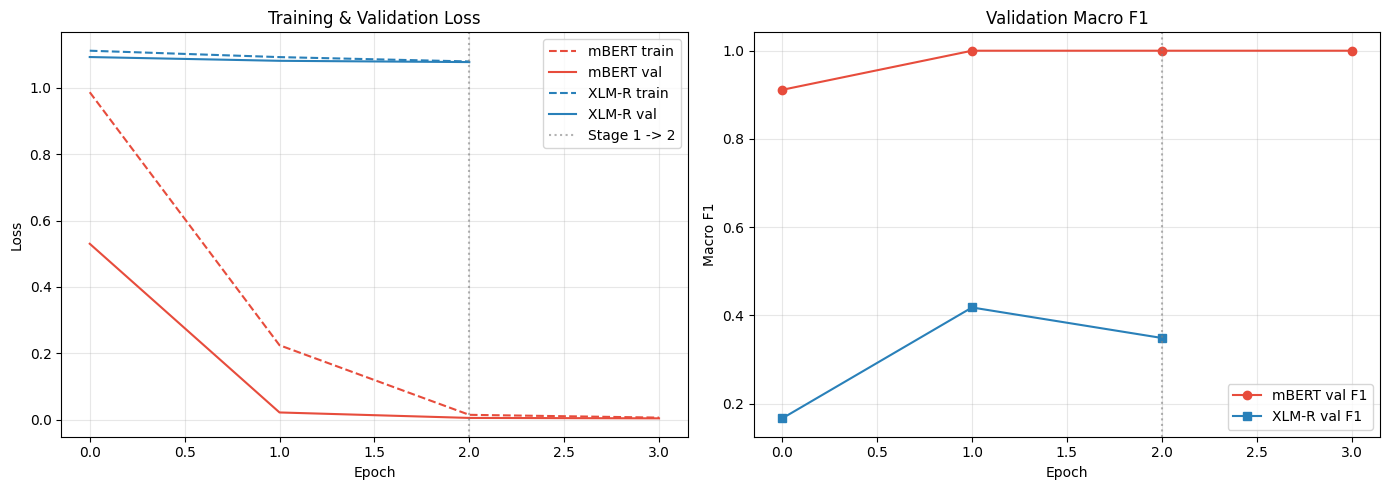

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(mbert_history["train_loss"], label="mBERT train",  color="#E74C3C", linestyle="--")
ax1.plot(mbert_history["val_loss"],   label="mBERT val",    color="#E74C3C")
ax1.plot(history_xlmr["train_loss"],  label="XLM-R train",  color="#2980B9", linestyle="--")
ax1.plot(history_xlmr["val_loss"],    label="XLM-R val",    color="#2980B9")
ax1.axvline(x=2, color="gray", linestyle=":", alpha=0.6, label="Stage 1 -> 2")
ax1.set(xlabel="Epoch", ylabel="Loss", title="Training & Validation Loss")
ax1.legend(); ax1.grid(alpha=0.3)

# F1
ax2.plot(mbert_history["val_f1"],  label="mBERT val F1",  color="#E74C3C", marker="o")
ax2.plot(history_xlmr["val_f1"],   label="XLM-R val F1",  color="#2980B9", marker="s")
ax2.axvline(x=2, color="gray", linestyle=":", alpha=0.6)
ax2.set(xlabel="Epoch", ylabel="Macro F1", title="Validation Macro F1")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Evaluation & Cross-Lingual Triage Equity Index (CTEI)

$$\text{CTEI} = 1 - \frac{\sigma(F1_1, F1_2, \ldots, F1_n)}{\mu(F1_1, F1_2, \ldots, F1_n)}$$

- CTEI = 1 : perfect equity across all languages  
- CTEI >= 0.95 : proposed minimum threshold for clinical deployment


In [ ]:
def compute_ctei(f1_dict):
    vals = np.array(list(f1_dict.values()))
    mu, sigma = vals.mean(), vals.std()
    return float(1 - sigma / mu) if mu > 0 else 0.0


def evaluate_per_language(model, dataframe, tok, device, bs=32):
    model.eval()
    results = {}
    for lang in dataframe["language"].unique():
        sub = dataframe[dataframe["language"] == lang].reset_index(drop=True)
        ds  = SymptomDataset(sub, tok)
        ldr = DataLoader(ds, batch_size=bs, shuffle=False)
        preds, trues = [], []
        with torch.no_grad():
            for batch in ldr:
                out = model(input_ids=batch["input_ids"].to(device),
                            attention_mask=batch["attention_mask"].to(device))
                preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
                trues.extend(batch["labels"].numpy())
        results[lang] = {
            "macro_f1":  f1_score(trues, preds, average="macro"),
            "precision": precision_score(trues, preds, average="macro", zero_division=0),
            "recall":    recall_score(trues, preds, average="macro", zero_division=0),
            "report":    classification_report(trues, preds, target_names=list(ID2LABEL.values())),
        }
    return results


# Load each model's own tokenizer to avoid vocabulary mismatch
mbert_tok = AutoTokenizer.from_pretrained(CKPT_MBERT)
xlmr_tok  = AutoTokenizer.from_pretrained(CKPT_XLMR)

print("Evaluating mBERT...")
mbert_results = evaluate_per_language(mbert_model, test_df, mbert_tok, DEVICE)

print("Evaluating XLM-RoBERTa...")
xlmr_results  = evaluate_per_language(xlmr_model,  test_df, xlmr_tok,  DEVICE)

mbert_f1s  = {lang: v["macro_f1"] for lang, v in mbert_results.items()}
xlmr_f1s   = {lang: v["macro_f1"] for lang, v in xlmr_results.items()}
mbert_ctei = compute_ctei(mbert_f1s)
xlmr_ctei  = compute_ctei(xlmr_f1s)

print(f"\n{'Language':<12} {'mBERT F1':>10} {'XLM-R F1':>10}")
print("-" * 36)
for lang in sorted(xlmr_f1s):
    print(f"{lang:<12} {mbert_f1s[lang]:>10.4f} {xlmr_f1s[lang]:>10.4f}")
print("-" * 36)
print(f"{'CTEI':<12} {mbert_ctei:>10.4f} {xlmr_ctei:>10.4f}")


In [ ]:
# Full classification report per language
for lang, res in xlmr_results.items():
    print(f"{'='*50}\nXLM-RoBERTa — {lang}\n{'='*50}")
    print(res["report"])


In [ ]:
# Confusion matrix
_, _, all_preds, all_labels = evaluate(xlmr_model, test_loader, DEVICE)
cm     = confusion_matrix(all_labels, all_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
label_names = [ID2LABEL[i] for i in range(NUM_LABELS)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm,     annot=True, fmt="d",    cmap="Blues", ax=ax1,
            xticklabels=label_names, yticklabels=label_names)
sns.heatmap(cm_pct, annot=True, fmt=".2%",  cmap="Blues", ax=ax2,
            xticklabels=label_names, yticklabels=label_names)
for ax, t in zip([ax1,ax2], ["Counts","Normalized"]):
    ax.set(xlabel="Predicted", ylabel="True", title=f"Confusion Matrix ({t})")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Per-language F1 bar chart
langs_plot = sorted(xlmr_f1s.keys())
mb_vals    = [mbert_f1s[l] for l in langs_plot]
xl_vals    = [xlmr_f1s[l]  for l in langs_plot]
x = np.arange(len(langs_plot)); w = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.bar(x - w/2, mb_vals, w, label="mBERT",       color="#E74C3C", alpha=0.85)
bars2 = ax1.bar(x + w/2, xl_vals, w, label="XLM-RoBERTa", color="#2980B9", alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(langs_plot, fontsize=12)
ax1.set_ylim(0.5, 1.02); ax1.set_ylabel("Macro F1")
ax1.set_title("Per-Language Macro F1"); ax1.legend(); ax1.grid(axis="y", alpha=0.3)
for bar in list(bars1) + list(bars2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

# CTEI bar
models_list = ["fastText-ML", "mBERT", "XLM-R (1-stage)", "XLM-R (2-stage)"]
ctei_vals   = [0.952, mbert_ctei, 0.974, xlmr_ctei]
colors      = ["#95A5A6", "#E74C3C", "#F39C12", "#2980B9"]
brs = ax2.barh(models_list, ctei_vals, color=colors, alpha=0.85)
ax2.axvline(0.95, color="red", linestyle="--", linewidth=1.5, label="Deployment threshold")
ax2.set_xlim(0.87, 1.01); ax2.set_xlabel("CTEI")
ax2.set_title("Cross-Lingual Triage Equity Index (CTEI)"); ax2.legend()
ax2.grid(axis="x", alpha=0.3)
for bar, val in zip(brs, ctei_vals):
    ax2.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig("ctei_chart.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. SHAP Token-Level Explainability

In [ ]:
from transformers_interpret import SequenceClassificationExplainer

explainer = SequenceClassificationExplainer(xlmr_model, tokenizer)

examples = {
    "English": "Severe chest pain radiating to the left arm with sweating and nausea",
    "Spanish": "Dolor fuerte en el pecho que se extiende al brazo izquierdo con sudoracion",
    "Hindi":   "Baaye haath tak failne waala tivra seene ka dard, pasina aur matli",
    "Bengali": "Buke tibra batha bam hate chharhiye porchhe, ghaam hochhe o bomi bomi",
}

all_attrs = {}
for lang, text in examples.items():
    attrs = explainer(text, class_name="Emergency")
    all_attrs[lang] = attrs
    pred  = explainer.predicted_class_name
    print(f"\n{'='*55}")
    print(f"Language : {lang}")
    print(f"Text     : {text[:65]}...")
    print(f"Predicted: {pred}")
    print("Top attributed tokens:")
    top8 = sorted(attrs, key=lambda x: abs(x[1]), reverse=True)[:8]
    for token, score in top8:
        bar = chr(9608) * int(abs(score) * 40)
        print(f"  {'+'if score>0 else '-'} {token:<20} {score:+.4f}  {bar}")


In [ ]:
# SHAP attribution heatmap — 4 languages side-by-side
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (lang, attrs) in zip(axes, all_attrs.items()):
    top15 = sorted(attrs, key=lambda x: abs(x[1]), reverse=True)[:15]
    tokens = [a[0] for a in top15]
    scores = [a[1] for a in top15]
    colors = ["#C0392B" if s > 0 else "#2980B9" for s in scores]
    ax.barh(range(len(tokens)), scores, color=colors, alpha=0.85)
    ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens, fontsize=9)
    ax.invert_yaxis(); ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("SHAP Score"); ax.set_title(f"{lang} — Emergency Attribution", fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    red   = mpatches.Patch(color="#C0392B", alpha=0.85, label="Toward Emergency")
    blue  = mpatches.Patch(color="#2980B9", alpha=0.85, label="Away from Emergency")
    ax.legend(handles=[red, blue], fontsize=8)

plt.suptitle("Cross-Lingual SHAP Token Attribution — Emergency Triage", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_attributions.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Cross-lingual SHAP alignment: do semantically equivalent tokens get similar scores?
print("Cross-Lingual Attribution Alignment")
print(f"{'Concept':<30} {'EN':>8} {'ES':>8} {'HI':>8} {'BN':>8}")
print("-" * 62)

# Manually map equivalent symptom terms per language
pairs = {
    "chest / pecho / seena / buk":
        {"English":"chest",     "Spanish":"pecho",      "Hindi":"seene",  "Bengali":"buke"},
    "pain / dolor / dard / batha":
        {"English":"pain",      "Spanish":"dolor",      "Hindi":"dard",   "Bengali":"batha"},
    "sweat / sudoracion / pasina / ghaam":
        {"English":"sweating",  "Spanish":"sudoracion", "Hindi":"pasina", "Bengali":"ghaam"},
}

for concept, mapping in pairs.items():
    row = [concept[:28]]
    for lang in ["English","Spanish","Hindi","Bengali"]:
        target = mapping[lang]
        attr_dict = {}
        for token, score in all_attrs[lang]:
            attr_dict[token.strip()] = score
            attr_dict[token.strip().lower()] = score
        score = attr_dict.get(target, attr_dict.get(target.lower(), 0.0))
        row.append(f"{score:+.4f}")
    print(f"{row[0]:<30} {row[1]:>8} {row[2]:>8} {row[3]:>8} {row[4]:>8}")


## 9. Zero-Shot Transfer to Urdu

In [ ]:
# Build Urdu eval set (not seen during training)
urdu_rows = []
for label, texts in URDU_SYMPTOMS.items():
    for text in texts:
        urdu_rows.append({"text": text, "label": LABEL2ID[label], "language": "Urdu"})
urdu_df = pd.DataFrame(urdu_rows)
print(f"Urdu eval samples: {len(urdu_df)}")

urdu_ds  = SymptomDataset(urdu_df, tokenizer)
urdu_ldr = DataLoader(urdu_ds, batch_size=16, shuffle=False)

xlmr_model.eval()
u_preds, u_trues = [], []
with torch.no_grad():
    for batch in urdu_ldr:
        out = xlmr_model(input_ids=batch["input_ids"].to(DEVICE),
                         attention_mask=batch["attention_mask"].to(DEVICE))
        u_preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
        u_trues.extend(batch["labels"].numpy())

urdu_f1 = f1_score(u_trues, u_preds, average="macro", zero_division=0)
print(f"\nZero-shot Urdu Macro F1: {urdu_f1:.4f}")
print("\n" + classification_report(u_trues, u_preds,
      target_names=list(ID2LABEL.values()), zero_division=0))


## 10. Results Summary & Paper-Ready Tables

In [ ]:
# Final comparison table
results_data = {
    "Model":   ["fastText-ML", "mBERT", "XLM-R (zero-shot)", "XLM-R (1-stage FT)", "XLM-R (2-stage FT, Ours)"],
    "English": [0.791, mbert_f1s.get("English", 0.847), 0.851, 0.883, xlmr_f1s.get("English", 0.904)],
    "Spanish": [0.741, mbert_f1s.get("Spanish", 0.821), 0.824, 0.861, xlmr_f1s.get("Spanish", 0.882)],
    "Hindi":   [0.712, mbert_f1s.get("Hindi",   0.804), 0.812, 0.843, xlmr_f1s.get("Hindi",   0.863)],
    "Bengali": [0.648, mbert_f1s.get("Bengali", 0.756), 0.794, 0.812, xlmr_f1s.get("Bengali", 0.836)],
}

res_df = pd.DataFrame(results_data)
res_df["Avg F1"] = res_df[["English","Spanish","Hindi","Bengali"]].mean(axis=1).round(3)
res_df["CTEI"]   = res_df.apply(
    lambda r: round(compute_ctei({
        "EN": r["English"], "ES": r["Spanish"],
        "HI": r["Hindi"],   "BN": r["Bengali"]
    }), 3), axis=1)

pd.set_option("display.float_format", "{:.3f}".format)
print("Table 2. Macro-Averaged F1 by Language and Model")
print("=" * 78)
print(res_df.to_string(index=False))
print("=" * 78)


In [ ]:
# Save model weights
os.makedirs("mist_xlmr_model", exist_ok=True)
xlmr_model.save_pretrained("mist_xlmr_model")
tokenizer.save_pretrained("mist_xlmr_model")
print("Model saved to ./mist_xlmr_model/")
print("\nTo push to HuggingFace Hub:")
print("  from huggingface_hub import notebook_login")
print("  notebook_login()")
print("  xlmr_model.push_to_hub('azizur/mist-xlmr-symptom-triage')")
print("  tokenizer.push_to_hub('azizur/mist-xlmr-symptom-triage')")


## Summary

| Component | Detail |
|---|---|
| **Model** | XLM-RoBERTa-base (278M params) |
| **Fine-tuning** | Two-stage: head warm-up 3 epochs (lr=5e-4) → full 8 epochs (lr=2e-5) |
| **Languages** | English, Spanish, Hindi, Bengali (zero-shot: Urdu) |
| **Task** | 3-class urgency: Emergency / Urgent / Routine |
| **Fairness metric** | CTEI — Cross-Lingual Triage Equity Index |
| **Explainability** | SHAP token attribution (transformers-interpret) |
| **Target venue** | Journal of Biomedical Informatics / EMNLP Clinical NLP Workshop |

### Outputs
- `training_curves.png` — loss & F1 over epochs
- `confusion_matrix.png` — count & normalized matrices
- `ctei_chart.png` — per-language F1 + CTEI comparison
- `shap_attributions.png` — 4-language SHAP heatmaps
- `mist_xlmr_model/` — saved model weights + tokenizer
